In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("GDP Per Country.csv")

In [7]:
df.info

<bound method DataFrame.info of          Country    2020      2021      2022      2023      2024      2025
0    Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
1        Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
2        Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
3        Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
4         Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0
..           ...     ...       ...       ...       ...       ...       ...
191      Vietnam  346310  370076.0  411068.0  433008.0  459472.0  490970.0
192    Palestine   15532   18109.0   19166.0   17848.0       NaN       NaN
193        Yemen   20220   19394.0   23534.0   19412.0   19101.0   17401.0
194       Zambia   18138   22096.0   29164.0   27578.0   26326.0   28910.0
195     Zimbabwe   26878   36016.0   32613.0   35144.0   35224.0   38172.0

[196 rows x 7 columns]>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [11]:
df.head

<bound method NDFrame.head of          Country    2020      2021      2022      2023      2024      2025
0    Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
1        Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
2        Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
3        Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
4         Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0
..           ...     ...       ...       ...       ...       ...       ...
191      Vietnam  346310  370076.0  411068.0  433008.0  459472.0  490970.0
192    Palestine   15532   18109.0   19166.0   17848.0       NaN       NaN
193        Yemen   20220   19394.0   23534.0   19412.0   19101.0   17401.0
194       Zambia   18138   22096.0   29164.0   27578.0   26326.0   28910.0
195     Zimbabwe   26878   36016.0   32613.0   35144.0   35224.0   38172.0

[196 rows x 7 columns]>

In [15]:
df.head(200)

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
...,...,...,...,...,...,...,...
191,Vietnam,346310,370076.0,411068.0,433008.0,459472.0,490970.0
192,Palestine,15532,18109.0,19166.0,17848.0,NaN,NaN
193,Yemen,20220,19394.0,23534.0,19412.0,19101.0,17401.0
194,Zambia,18138,22096.0,29164.0,27578.0,26326.0,28910.0


In [21]:
df.isnull().sum()

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

In [23]:
df=df.dropna()

In [25]:
if df.columns.str.contains(r'^\d{4}$').any():  
    df_long = df.melt(id_vars=[df.columns[0]], 
                      var_name="Year", 
                      value_name="GDP")
    df_long["Year"] = df_long["Year"].astype(int)
else:
    df_long = df.copy()

In [29]:
latest_year = df_long["Year"].max()

In [31]:
top_countries = (df_long[df_long["Year"] == latest_year]
                 .sort_values(by="GDP", ascending=False)
                 .head(10))
print("\nTop 10 Countries in", latest_year)
print(top_countries)


Top 10 Countries in 2025
             Country  Year         GDP
1125   United States  2025  30507217.0
980            China  2025  19231705.0
1007         Germany  2025   4744804.0
1020           India  2025   4187017.0
1028           Japan  2025   4186431.0
1124  United Kingdom  2025   3839180.0
1003          France  2025   3211292.0
1026           Italy  2025   2422855.0
976           Canada  2025   2225341.0
968           Brazil  2025   2125958.0


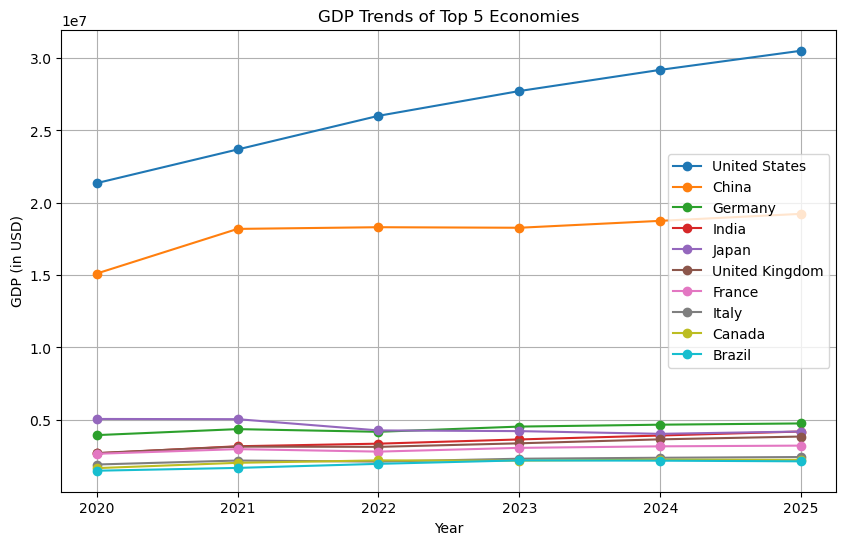

In [51]:
top5 = top_countries[df.columns[0]].tolist()
plt.figure(figsize=(10,6))
for country in top5:
    subset = df_long[df_long[df.columns[0]] == country]
    plt.plot(subset["Year"], subset["GDP"], marker="o", label=country)
plt.title("GDP Trends of Top 5 Economies")
plt.xlabel("Year")
plt.ylabel("GDP (in USD)")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_26720\3151201048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


TypeError: 'str' object is not callable

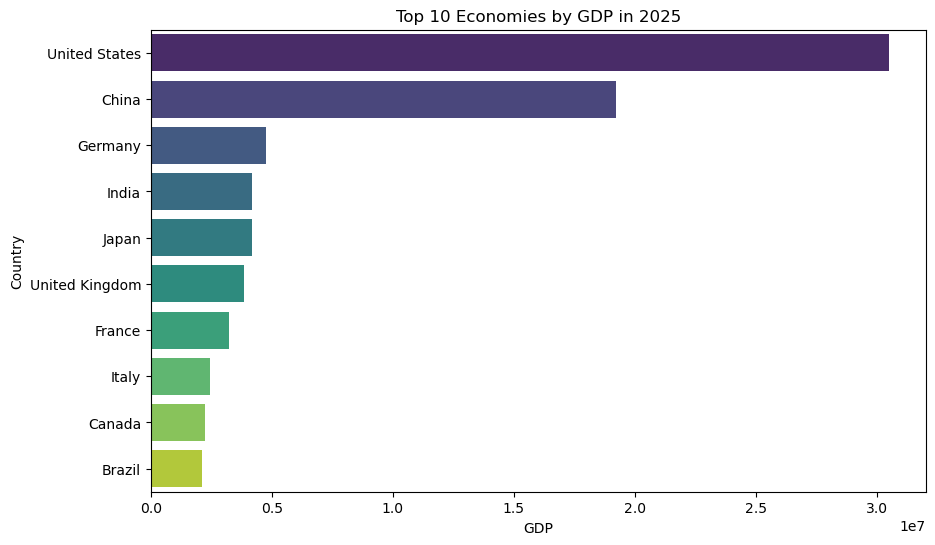

In [65]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_countries, 
    x="GDP", 
    y=df.columns[0], 
    palette="viridis"
)
plt.title(f"Top 10 Economies by GDP in {latest_year}")
plt.xlabel("GDP (in USD)")  
plt.ylabel("Country")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

TypeError: 'str' object is not callable

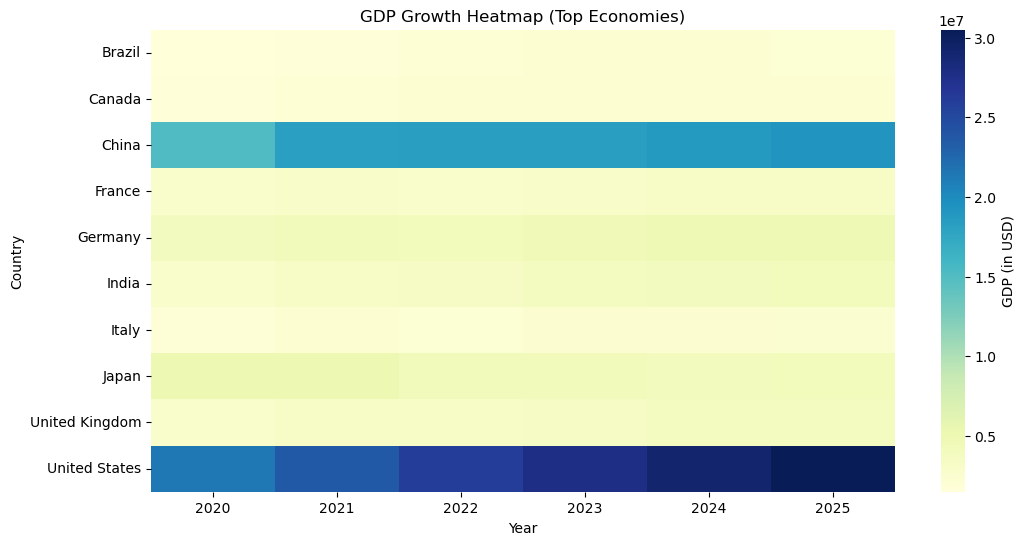

In [69]:
pivot_data = df_long[df_long[df.columns[0]].isin(top5)].pivot(
    index=df.columns[0],   # usually "Country Name"
    columns="Year",
    values="GDP"
)

plt.figure(figsize=(12,6))
sns.heatmap(
    pivot_data, 
    annot=False, 
    cmap="YlGnBu", 
    cbar_kws={'label': 'GDP (in USD)'}
)
plt.title("GDP Growth Heatmap (Top Economies)")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()